# Prototype: per-sender EMA baseline for recipient diversity (SS7)
**Question:** does comparing a sender's *current* diversity ratio to *its own* smoothed history add signal beyond the ratios we already have (`sender_recipient_diversity_ratio_5min/_1hr`)?

**Nothing here touches the pipeline.** It reads `messages_with_behavioral.csv`, builds candidate features in the notebook, and compares them with the same relevance/redundancy/ablation tools as `feature_redundancy_analysis.ipynb`.

**Design (mirrors `features/identity_baseline.py`: EMA level + residual spread, then a z-score):**
1. Bucket each sender's traffic into 5-min buckets: `m` = messages, `u` = distinct destinations.
2. Baseline as of a bucket = EMA over the sender's **strictly earlier** active buckets. Two variants:
   - **ratio_of_ema** = EMA(u) / EMA(m) (volume-weighted; no hard gate needed for low-volume buckets)
   - **ema_of_ratio** = EMA(u/m), gated to buckets with m >= 3 (for comparison)
3. Message feature = current gated 5-min ratio (already point-in-time) minus baseline, and that divided by the sender's EMA residual spread (floored, like `MIN_SPREAD`).

**Point-in-time rule:** baseline for bucket *k* uses buckets < *k* only. Section 4 proves this by truncation test.

In [1]:
import os, sys, warnings
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "scripts").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import GroupShuffleSplit
import lightgbm as lgb
from scripts.analyze_feature_redundancy import spearman
from models.anomaly.data import BEHAVIORAL_COLS

BUCKET = "5min"
MIN_MSGS = 3          # same gate as SENDER_DIVERSITY_MIN_MSGS
MIN_HISTORY = 2       # prior active buckets required before the baseline counts as "known"
MIN_SPREAD = 0.05     # floor on z-score denominator (same idea as identity_baseline.MIN_SPREAD)
ALPHA = 0.1           # unvalidated starting point, swept in section 7
CACHE = ROOT / "data/processed/feature_analysis"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25})

## 1. Load SS7 (full corpus, only the columns needed), sorted by sender + time

In [2]:
fp = CACHE / "ss7_ema_input.parquet"
if not fp.exists():
    use = ["originator", "destination", "timestamp", "rule_evaluated", "rule_flagged", "is_platform_token_message",
           "sender_recipient_diversity_ratio_5min", "sender_recipient_diversity_ratio_1hr",
           "imsi_distinct_originators_1hr", "sender_velocity_zscore_5min"] + BEHAVIORAL_COLS
    d = pd.read_csv(ROOT / "data/processed/SS7/messages_with_behavioral.csv", usecols=lambda c: c in set(use))
    if "is_platform_token_message" in d:
        d = d[~d["is_platform_token_message"].fillna(False).astype(bool)].drop(columns="is_platform_token_message")
    d["ts"] = pd.to_datetime(d["timestamp"]); d = d.drop(columns="timestamp")
    d["rule_evaluated"] = d["rule_evaluated"].astype(bool)
    d = d.sort_values(["originator", "ts"], kind="stable").reset_index(drop=True)
    d.to_parquet(fp)
df = pd.read_parquet(fp)
df["bucket"] = df["ts"].dt.floor(BUCKET)
print(f"{len(df):,} messages | {df.originator.nunique():,} senders | {df.ts.min()} .. {df.ts.max()}")

2,742,301 messages | 834 senders | 2026-08-02 00:00:00 .. 2026-08-03 23:59:59


## 2. Bucket table (per sender x 5-min bucket)

In [3]:
g = (df.groupby(["originator", "bucket"], sort=True)
       .agg(m=("destination", "size"), u=("destination", "nunique")).reset_index())
g["r"] = np.where(g.m >= MIN_MSGS, g.u / g.m, np.nan)      # gated bucket ratio
print(f"{len(g):,} (sender, bucket) rows; buckets per sender: median {g.groupby('originator').size().median():.0f}, "
      f"max {g.groupby('originator').size().max():,}")

19,279 (sender, bucket) rows; buckets per sender: median 2, max 576


## 3. The baseline builder (strictly-prior state)

In [4]:
def build_baseline(g, alpha=ALPHA, mode="ratio_of_ema"):
    """Adds base_prior / spread_prior / n_prior to bucket table g (sorted by originator, bucket).
    Every *_prior value at bucket k is computed from buckets < k of the same sender (shift(1) after the EMA)."""
    g = g.copy(); grp = g.groupby("originator", sort=False)
    def ema(col):
        return grp[col].ewm(alpha=alpha, adjust=False, ignore_na=True).mean().reset_index(level=0, drop=True)
    if mode == "ratio_of_ema":
        base_incl = ema("u") / ema("m")                      # state INCLUDING this bucket
    else:                                                     # ema_of_ratio (gated)
        base_incl = ema("r")
    g["_base_incl"] = base_incl
    g["base_prior"] = g.groupby("originator", sort=False)["_base_incl"].shift(1)
    resid = (g["r"] - g["base_prior"]).abs()                  # bucket residual vs the PRIOR baseline
    g["_res"] = resid
    spread_incl = g.groupby("originator", sort=False)["_res"].ewm(alpha=alpha, adjust=False, ignore_na=True).mean().reset_index(level=0, drop=True)
    g["_spread_incl"] = spread_incl
    g["spread_prior"] = g.groupby("originator", sort=False)["_spread_incl"].shift(1)
    g["n_prior"] = g.groupby("originator", sort=False).cumcount()
    return g.drop(columns=["_base_incl", "_res", "_spread_incl"])

def message_features(df, gb):
    m = df.merge(gb[["originator", "bucket", "base_prior", "spread_prior", "n_prior"]], on=["originator", "bucket"], how="left")
    cur = m["sender_recipient_diversity_ratio_5min"].where(m["sender_msgs_last_5min"] >= MIN_MSGS)   # gated, point-in-time
    known = m["base_prior"].notna() & (m["n_prior"] >= MIN_HISTORY) & cur.notna()
    m["div_cur"] = cur
    m["div_baseline"] = m["base_prior"].where(known)
    m["div_dev"] = (cur - m["base_prior"]).where(known)
    m["div_z"] = (m["div_dev"] / m["spread_prior"].clip(lower=MIN_SPREAD)).where(known)
    return m

gb = build_baseline(g, ALPHA, "ratio_of_ema")
mf = message_features(df, gb)
print("known fraction of all messages:", round(mf.div_z.notna().mean(), 3))
display(gb.head(8))

known fraction of all messages: 0.991


,originator,bucket,m,u,r,base_prior,spread_prior,n_prior
0,358400,2026-08-03 04:55:00,1,1,NaN,NaN,NaN,0
1,491552,2026-08-03 05:00:00,1,1,NaN,NaN,NaN,0
2,819060,2026-08-02 04:55:00,1,1,NaN,NaN,NaN,0
3,819060,2026-08-03 05:00:00,1,1,NaN,1.0,NaN,1
4,1111111,2026-08-03 03:55:00,1,1,NaN,NaN,NaN,0
5,4917600,2026-08-02 05:05:00,1,1,NaN,NaN,NaN,0
6,84900403,2026-08-02 08:30:00,1,1,NaN,NaN,NaN,0
7,84900403,2026-08-02 15:10:00,1,1,NaN,1.0,NaN,1


## 4. Point-in-time proof (truncation test)
Recompute the baseline from data truncated at bucket *k*; the value at *k* must equal the full-data value. If any future bucket leaked in, these differ.

In [5]:
rng = np.random.default_rng(0)
busy = g.groupby("originator").size().sort_values(ascending=False).head(200).index
bad = 0; checks = 0
for mode in ("ratio_of_ema", "ema_of_ratio"):
    full = build_baseline(g, ALPHA, mode).set_index(["originator", "bucket"])
    for s in rng.choice(busy, 8, replace=False):
        gs = g[g.originator == s].reset_index(drop=True)
        k = int(rng.integers(3, len(gs)))
        trunc = build_baseline(gs.iloc[:k + 1], ALPHA, mode).set_index(["originator", "bucket"])
        key = (s, gs.bucket.iloc[k])
        for col in ("base_prior", "spread_prior"):
            a, b = full.loc[key, col], trunc.loc[key, col]
            checks += 1; bad += not (np.isclose(a, b, equal_nan=True))
print(f"{checks} checks, {bad} mismatches ->", "POINT-IN-TIME VALID" if bad == 0 else "LEAK")

32 checks, 0 mismatches -> POINT-IN-TIME VALID


## 5. Coverage & cold start
The EMA is only useful where a sender has history. This sample is ~2 days, so cold starts will be common.

In [6]:
print("share of messages by prior-bucket history:")
print(pd.cut(mf.n_prior.fillna(0), [-1, 0, 1, 5, 20, 100, np.inf], labels=["0", "1", "2-5", "6-20", "21-100", ">100"]).value_counts(normalize=True).sort_index().round(3).to_string())
print("\nmessages with gated current ratio:", round(mf.div_cur.notna().mean(), 3), "| with known EMA feature:", round(mf.div_z.notna().mean(), 3))
lab_share = mf.loc[mf.rule_evaluated, "div_z"].notna().mean(); print("known share within labelled pool:", round(lab_share, 3))

share of messages by prior-bucket history:
n_prior
0         0.002
1         0.002
2-5       0.007
6-20      0.020
21-100    0.076
>100      0.894

messages with gated current ratio: 0.995 | with known EMA feature: 0.991
known share within labelled pool: 0.991


## 6. What it looks like: busiest senders (bucket ratio vs its EMA baseline, +/- 2 spread)

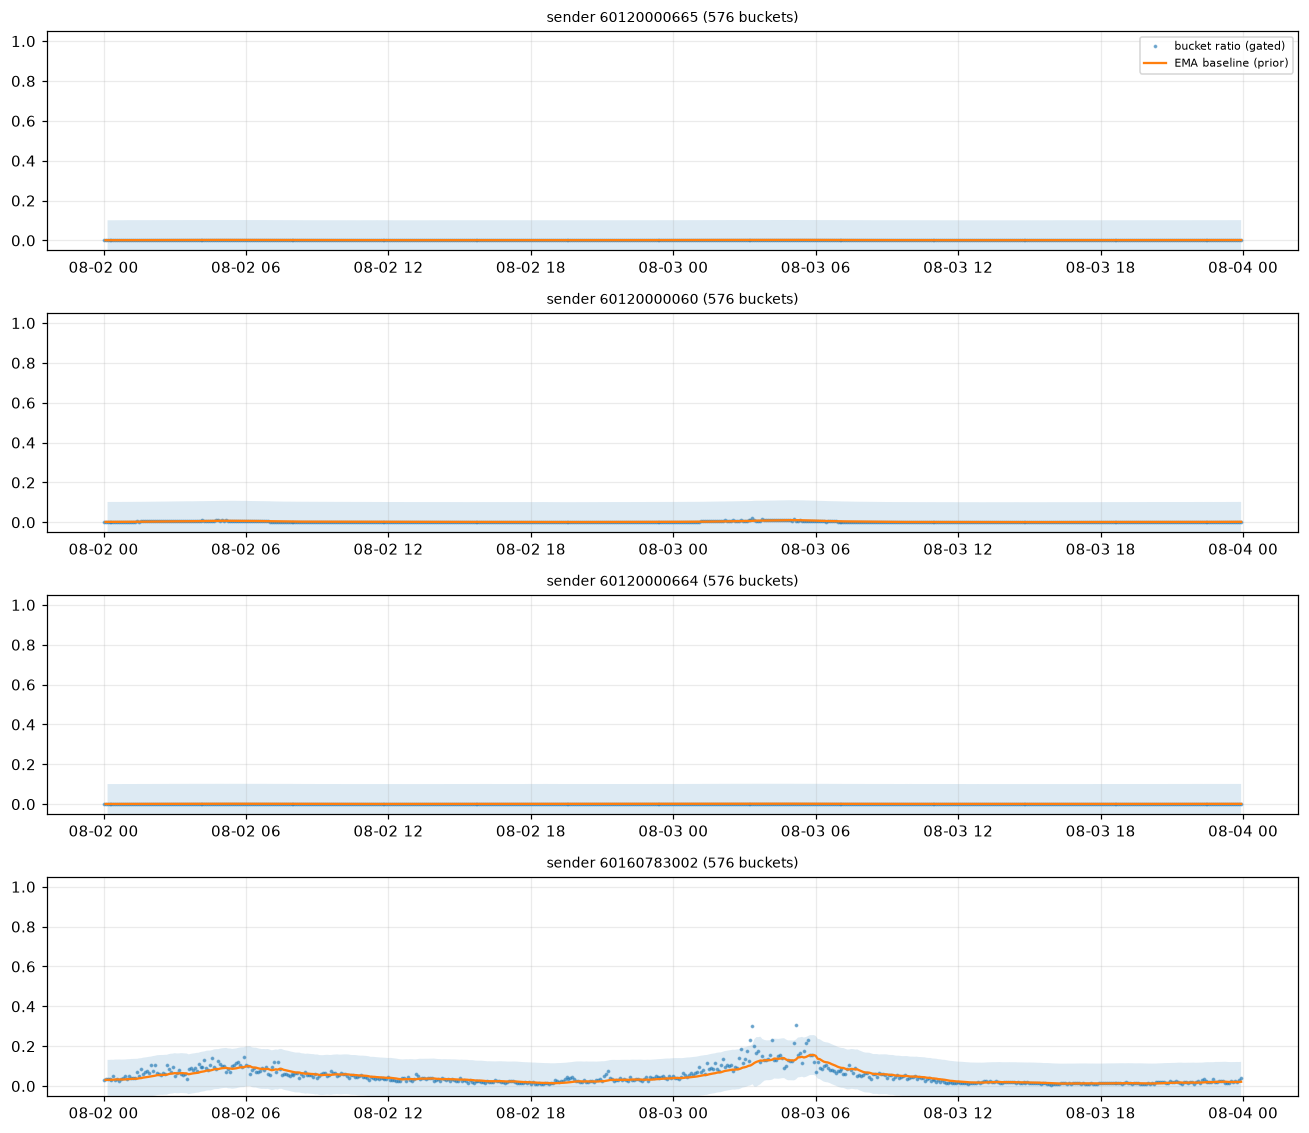

In [7]:
top = g.groupby("originator").size().sort_values(ascending=False).head(4).index
fig, axs = plt.subplots(len(top), 1, figsize=(12, 2.6 * len(top)), sharex=False)
for ax, s in zip(np.atleast_1d(axs), top):
    x = gb[gb.originator == s]
    ax.plot(x.bucket, x.r, ".", ms=3, alpha=.5, label="bucket ratio (gated)")
    ax.plot(x.bucket, x.base_prior, lw=1.5, label="EMA baseline (prior)")
    sp = x.spread_prior.clip(lower=MIN_SPREAD)
    ax.fill_between(x.bucket, x.base_prior - 2 * sp, x.base_prior + 2 * sp, alpha=.15)
    ax.set_title(f"sender {s} ({len(x)} buckets)", fontsize=9); ax.set_ylim(-0.05, 1.05)
np.atleast_1d(axs)[0].legend(fontsize=7); plt.tight_layout(); plt.show()

## 7. Does it carry label signal? Variants x alpha (marginal, rough)
Labelled pool = `rule_evaluated` rows, random 300k subsample. Remember: marginal signal understates interaction value - section 9 is the real test.

In [8]:
lab_all = mf[mf.rule_evaluated].copy()
lab = lab_all.sample(min(300_000, len(lab_all)), random_state=0).reset_index(drop=True)
y = lab["rule_flagged"].astype(float)
print(f"labelled subsample {len(lab):,}, positive rate {y.mean():.4f}, senders {lab.originator.nunique():,}")

def marginal(col, frame=None):
    frame = lab if frame is None else frame; yy = frame["rule_flagged"].astype(float); s = frame[col]; ok = s.notna()
    return dict(feature=col, n=int(ok.sum()), auc_dist=abs(roc_auc_score(yy[ok], s[ok]) - .5), spearman_y=spearman(s, yy))

rows = [marginal("sender_recipient_diversity_ratio_5min"), marginal("sender_recipient_diversity_ratio_1hr"), marginal("div_cur")]
for mode in ("ratio_of_ema", "ema_of_ratio"):
    for a in (0.05, 0.1, 0.3):
        gb_ = build_baseline(g, a, mode); m_ = message_features(df[df.rule_evaluated], gb_)
        sub = m_.sample(min(300_000, len(m_)), random_state=0).reset_index(drop=True)
        for c in ("div_dev", "div_z"):
            r = marginal(c, sub); r["feature"] = f"{c} [{mode}, alpha={a}]"; rows.append(r)
res7 = pd.DataFrame(rows); display(res7.round(4))

labelled subsample 300,000, positive rate 0.1070, senders 396


,feature,n,auc_dist,spearman_y
0,sender_recipient_diversity_ratio_5min,300000,0.0366,-0.0392
1,sender_recipient_diversity_ratio_1hr,300000,0.0342,-0.0367
2,div_cur,298424,0.0365,-0.0391
3,"div_dev [ratio_of_ema, alpha=0.05]",297325,0.0300,0.0321
4,"div_z [ratio_of_ema, alpha=0.05]",297307,0.0303,0.0325
5,"div_dev [ratio_of_ema, alpha=0.1]",297325,0.0192,0.0205
6,"div_z [ratio_of_ema, alpha=0.1]",297307,0.0194,0.0207
7,"div_dev [ratio_of_ema, alpha=0.3]",297325,0.0107,0.0114
8,"div_z [ratio_of_ema, alpha=0.3]",297307,0.0107,0.0115
9,"div_dev [ema_of_ratio, alpha=0.05]",297310,0.0401,0.0430


## 8. Is it new information? Spearman vs existing behavioural features (default variant), with boundedness check

,div_dev,div_z,div_baseline
sender_msgs_last_5min,-0.134,-0.134,-0.790
sender_msgs_last_1hr,0.024,0.024,-0.817
sender_unique_destinations_1hr,-0.126,-0.127,0.670
sender_repeat_content_ratio_1hr,-0.068,-0.068,0.082
sender_age_days,0.039,0.039,-0.109
sender_recipient_diversity_ratio_5min,0.066,0.067,0.958
sender_recipient_diversity_ratio_1hr,-0.090,-0.089,0.936
div_cur,0.066,0.067,0.958


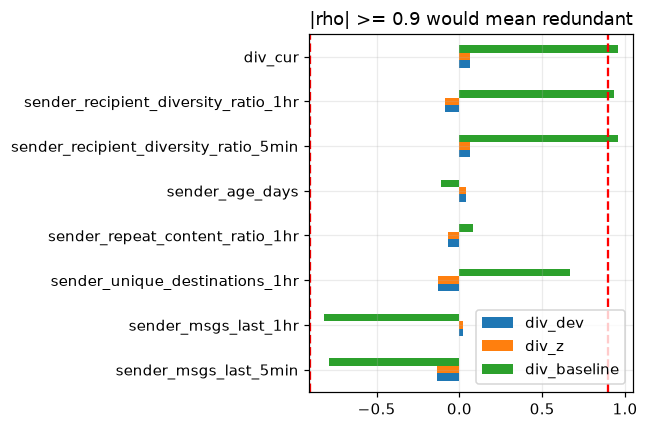

div_cur vs div_dev: {'rho_interior': np.float64(0.066), 'rho_within_msg_strata': np.float64(0.073)}


sender_recipient_diversity_ratio_1hr vs div_dev: {'rho_interior': np.float64(-0.09), 'rho_within_msg_strata': np.float64(-0.088)}


In [9]:
from scripts.analyze_feature_redundancy import boundedness_check
Xc = lab[BEHAVIORAL_COLS + ["div_cur", "div_baseline", "div_dev", "div_z"]].astype(float)
c8 = Xc.corr(method="spearman")[["div_dev", "div_z", "div_baseline"]].drop(["div_dev", "div_z", "div_baseline"])
display(c8.round(3))
fig, ax = plt.subplots(figsize=(6, 4)); c8.plot.barh(ax=ax); ax.axvline(.9, c="r", ls="--"); ax.axvline(-.9, c="r", ls="--")
ax.set_title("|rho| >= 0.9 would mean redundant"); plt.tight_layout(); plt.show()
for other in ("div_cur", "sender_recipient_diversity_ratio_1hr"):
    print(other, "vs div_dev:", {k: round(v, 3) if isinstance(v, float) else v for k, v in boundedness_check(Xc.assign(sender_msgs_last_1hr=lab["sender_msgs_last_1hr"]), other, "div_dev", .9).items() if k.startswith("rho")})

## 9. Incremental value in a model (behavioural-only LightGBM, originator-grouped splits)
Baseline = current behavioural features. Variants add EMA features. Differences smaller than the split std are noise. Not the production model (no content flags), so read the *delta*.

groups: 396


,variant,pr_auc,std,delta
0,baseline (current behavioural),0.2323,0.0902,0.0000
1,+ div_dev,0.2409,0.0961,0.0086
2,+ div_z,0.2360,0.0989,0.0036
3,"+ div_dev, div_z, div_baseline",0.2423,0.0988,0.0099
4,"swap: drop raw ratios, add EMA trio",0.2451,0.0949,0.0128


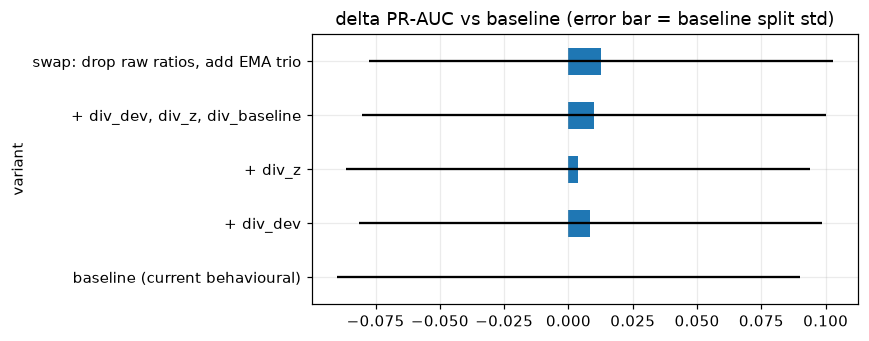

In [10]:
base_cols = BEHAVIORAL_COLS + [c for c in ("imsi_distinct_originators_1hr", "sender_velocity_zscore_5min") if c in lab.columns]
yy = y.astype(int).to_numpy(); grp = lab["originator"].to_numpy()
print("groups:", len(np.unique(grp)))
def cv(cols, n=3):
    aps = []
    for s in range(n):
        a, b = next(GroupShuffleSplit(1, test_size=.3, random_state=s).split(lab, yy, grp))
        m = lgb.LGBMClassifier(n_estimators=250, learning_rate=.08, num_leaves=31, min_child_samples=50, subsample=.8,
                               subsample_freq=1, colsample_bytree=.8, verbose=-1, random_state=s)
        m.fit(lab.iloc[a][cols], yy[a]); aps.append(average_precision_score(yy[b], m.predict_proba(lab.iloc[b][cols])[:, 1]))
    return np.mean(aps), np.std(aps)
variants = {"baseline (current behavioural)": base_cols,
            "+ div_dev": base_cols + ["div_dev"],
            "+ div_z": base_cols + ["div_z"],
            "+ div_dev, div_z, div_baseline": base_cols + ["div_dev", "div_z", "div_baseline"],
            "swap: drop raw ratios, add EMA trio": [c for c in base_cols if "diversity_ratio" not in c] + ["div_cur", "div_dev", "div_z", "div_baseline"]}
r9 = []
for n, cols_ in variants.items():
    mu, sd = cv(cols_); r9.append((n, mu, sd))
r9 = pd.DataFrame(r9, columns=["variant", "pr_auc", "std"]); r9["delta"] = r9.pr_auc - r9.pr_auc.iloc[0]; display(r9.round(4))
ax = r9.set_index("variant")["delta"].plot.barh(figsize=(8, 3.2), xerr=r9["std"].iloc[0]); ax.set_title("delta PR-AUC vs baseline (error bar = baseline split std)"); plt.tight_layout(); plt.show()

## 10. How to decide
- **Point-in-time (section 4):** must say VALID, otherwise stop.
- **Coverage (5):** if most labelled rows are cold-start, the feature can't matter much on this sample regardless of merit - re-test on longer history.
- **New information (8):** |rho| against existing ratios well below 0.9 and the boundedness check not collapsing = not redundant.
- **Value (9):** promote only if delta clears the split std. A weak marginal (7) with a real delta (9) is the interaction case; a weak marginal with no delta means drop it.
- Only then consider the streaming implementation (state per sender = EMA(u), EMA(m), residual spread) in `features/identity_baseline.py`'s generic `update_baseline()`.